# ** Projeto de Doenças Cardiovasculares - Regressão Logística**


Nesse projeto construiremos um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Nosso objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Carregamento e tratamento da base

In [ ]:
#Carregando a base
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')
df = pd.DataFrame(base)

In [ ]:
#Verificando os dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [ ]:
df['weight'].unique() #Entendendo porque o formato do dado não é .float

array(['62', '85', '64', '82', '56', '67', '93', '95', '71', '68', '80',
       '60', '78', '112', '75', '52', '83', '69', '90', '45', '65', '59',
       '66', '74', '105', '73', '55', '70', '72', '63', '50', '107', '84',
       '77', '79', '76', '58', '115', '97', '53', '57', '49', '110', '94',
       '92', '87', '103', '88', '99', '100', '61', '48', '54', '51', '47',
       '91', '104', '81', '98', '108', '89', '101', '86', '65,5', '142',
       '96', '44', '41', '169', '116', '200', '64,8', '120', '117', '125',
       '106', '114', '113', '129', '124', '42', '123', '111', '102',
       '109', '46', '139', '150', '138', '131', '43', '83,6', '134',
       '106,5', '121', '40', '141', '119', '126', '177', '165', '122',
       '62,3', '118', '89,5', '132', '155', '130', '159', '84,6', '140',
       '82,3', '30', '67,9', '127', '67,5', '74,3', '149', '180', '128',
       '60,2', '64,5', '58,7', '90,5', '37', '80,8', '166', '161', '92,2',
       '75,6', '136', '82,9', '154', '68,9', '170'

In [ ]:
#Corrigindo os dados para float
df['weight'] = df['weight'].str.replace(',', '.')
df['weight'] = df['weight'].astype(float)

In [ ]:
print(df['weight'].dtypes) #Verificado

float64


In [ ]:
df.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Nesta análise, percebemos a altura e peso com medianas próximas à média, o que nos permite entender que não há outliers. No entanto, os valores mínimos e máximos dessas features são um pouco suspeitas e precisamos analisar com mais detalhes.

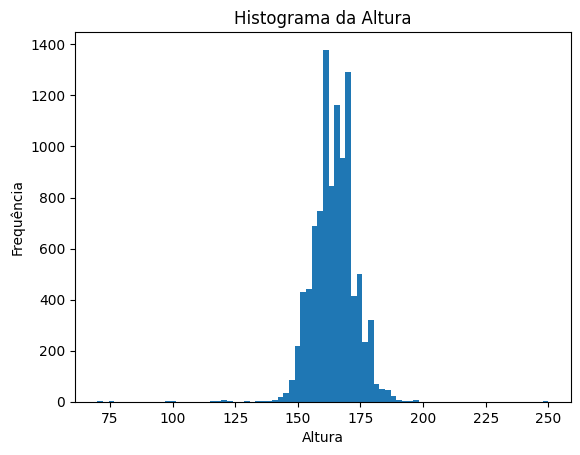

In [ ]:
#Análise de outliers por histograma da altura
plt.hist(df['height'], bins=80)
plt.xlabel('Altura')
plt.ylabel('Frequência')
plt.title('Histograma da Altura')
plt.show()

Percebemos que há pessoas com alturas distantes da maior concentração. Neste caso, optamos pela interpretação como outliers e sua remoção pelo método IQR.

In [ ]:
#Removendo os outliers das alturas pelo método IQR
Q1 = df['height'].quantile(0.25)
Q3 = df['height'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
df = df[(df['height'] >= limite_inferior) & (df['height'] <= limite_superior)]

In [ ]:
df['height'].describe()

,height
count,9926.000000
mean,164.309792
std,7.619069
min,143.000000
25%,159.000000
50%,165.000000
75%,170.000000
max,186.000000


Note que a média ficou ainda mais próxima da mediana e o valor mínimo parece mais aceitável. Vamos repetir o mesmo processo para os dado de peso.

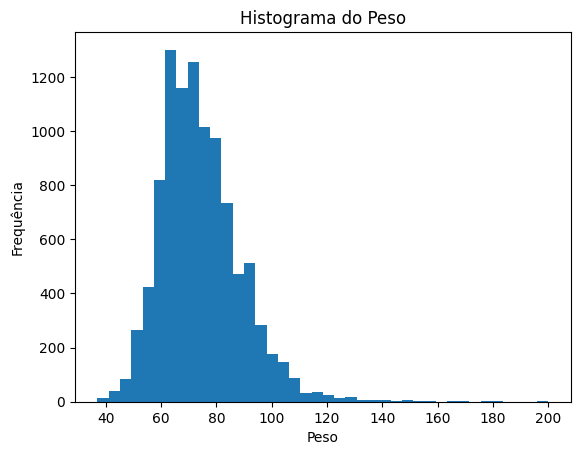

In [ ]:
#Analisando outliers dos pesos
plt.hist(df['weight'], bins=40)
plt.xlabel('Peso')
plt.ylabel('Frequência')
plt.title('Histograma do Peso')
plt.show()

Embora não descartamos a possibilidade de pessoas terem o peso descrito, optamos peça interpretação como outlier para focar no agrupamento das pessoas e melhores métricas do modelo.

In [ ]:
#Removendo os outliers dos pesos pelo método IQR
Q1 = df['weight'].quantile(0.25)
Q3 = df['weight'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
df = df[(df['weight'] >= limite_inferior) & (df['weight'] <= limite_superior)]

In [ ]:
df['weight'].describe()

,weight
count,9691.000000
mean,73.127861
std,12.481906
min,40.000000
25%,65.000000
50%,72.000000
75%,81.000000
max,107.000000


Mais uma vez, a média mais próxima da mediana.

# 2) Exploração e visualização dos dados.



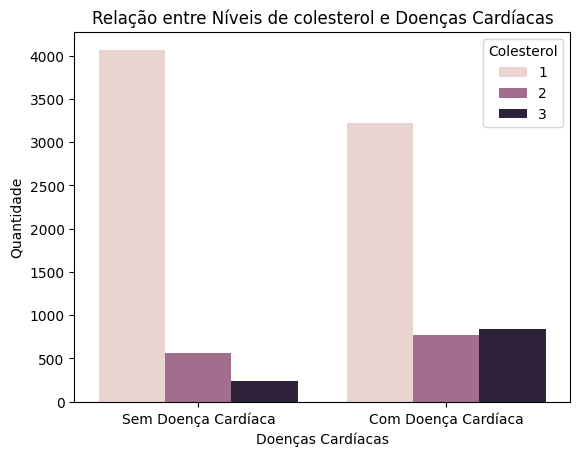

In [ ]:
#Gráfico de barras bivariado
ax = sns.countplot(x='cardio_disease', hue = 'cholesterol', data=df)
plt.title('Relação entre Níveis de colesterol e Doenças Cardíacas')
plt.xticks(ticks=[0, 1], labels=['Sem Doença Cardíaca', 'Com Doença Cardíaca'])  # Change x-axis labels
plt.xlabel('Doenças Cardíacas')
plt.ylabel('Quantidade')

# Change legend labels and title
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['1', '2', '3'], title='Colesterol')

plt.show()

Esse gráfico de barras nos mostra que pessoas com níveis de colesterol mais alto (2 e 3) se concentram mais no grupo de pessoas com doeças cardíacas e pessoas com nível de colesterol mais baixo (1) estão mais presentes no grupo de pessoas sem doenças cardíacas.

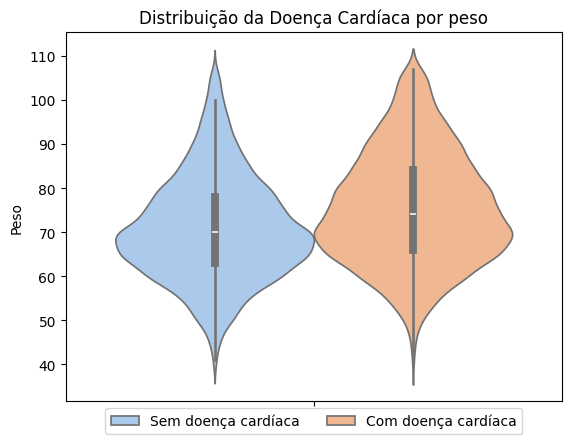

In [ ]:
#Gráfico violino Bivariado
sns.violinplot(hue='cardio_disease', y='weight', legend=True, data=df, palette='pastel')
plt.title('Distribuição da Doença Cardíaca por peso')
plt.ylabel('Peso')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Sem doença cardíaca', 'Com doença cardíaca'], title='',
           bbox_to_anchor=(0.5, -0.), loc='upper center', ncol=2)


Apesar de serem semelhantes, notamos que há uma maior densidade de pessoas com doença cardíaca com maior peso do que as pessoas sem doença cardíaca. Note que a mediana dos pesos de pessoas do grupo laranja é maior do que a mediana das pessoas do grupo azul.

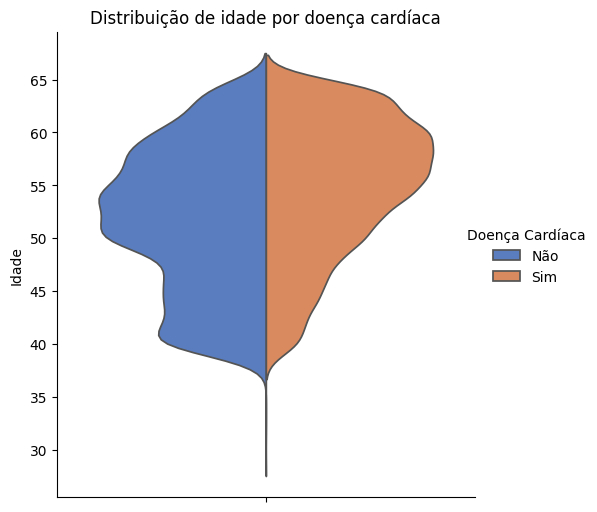

In [ ]:
#Gráfico violino bivariado dividido.
g = sns.catplot(y = 'age', hue = 'cardio_disease', data = df, kind = 'violin', split = True, palette='muted', inner = None)
plt.ylabel('Idade')
plt.title('Distribuição de idade por doença cardíaca')

g._legend.set_title("Doença Cardíaca")
g._legend.texts[0].set_text("Não")
g._legend.texts[1].set_text("Sim")

plt.show()

Note que há uma maior concentração de pessoas com doença cardíaca entre os 55 e 65 anos. Em contrapartida, a concentração de pessoas sem doenças cardíacas entre os 50 e 60 anos.

# 3) Matriz de correlação.



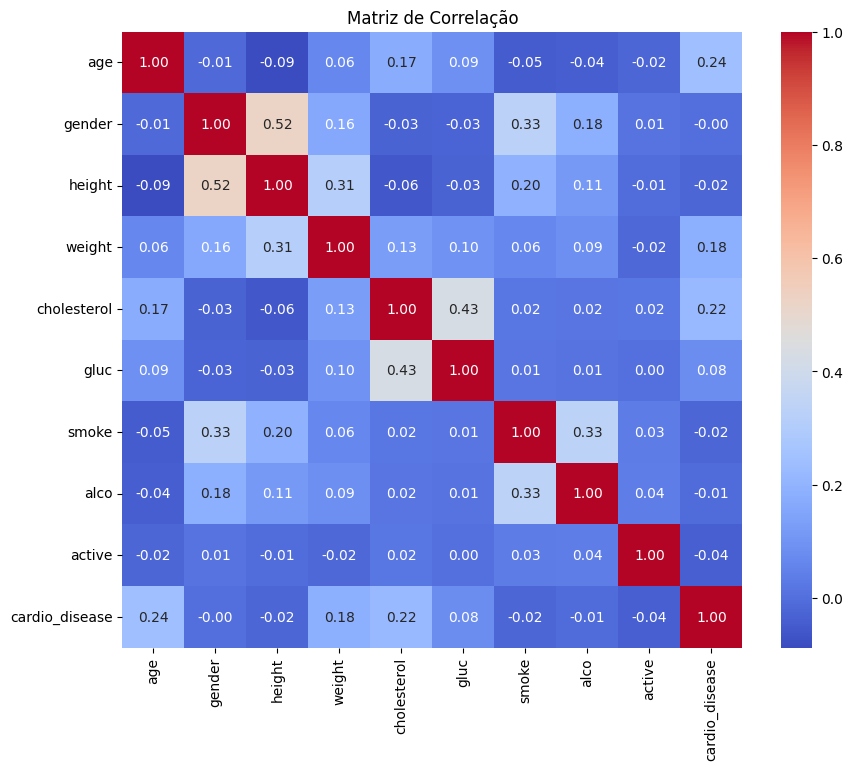

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

As varíaveis com maiores correlações são gênero x altura, colesterol x glicose, cigarro x alcool. Contudo, a correlação mais significante é de gênero e altura (0,52) o que nos permite dizer que não há correlações muito forte entre os dados.

# 4) Etapa pré modelo.

In [ ]:
#Separando a variável target do DataFrame
X = df.drop('cardio_disease', axis=1)
y = df['cardio_disease']

In [ ]:
#Separando as bases de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Neste modelos, achamos necessário a padronização das varíaveis pois a regressão logística é sensivel a escala das variáveis. Como temos dados contínuos e de diferentes espectros, faremos a padronização.

In [ ]:
#padronizando as variáveis
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Verificando o balanceamento.
df['cardio_disease'].value_counts()

,count
cardio_disease,
0,4865
1,4826


Verificamos que a quantidade de classes binárias é muito próxima, por isso a consideramos já balanceadas, evitando o procedimento de balanceamento.

In [ ]:
X_train

array([[-0.63399324, -0.72090361, -0.56025351, ..., -0.31058643,
        -0.23994087,  0.50334371],
       [ 0.39523578, -0.72090361, -0.42812838, ..., -0.31058643,
        -0.23994087, -1.98671401],
       [ 0.39523578,  1.38714799,  0.36462241, ..., -0.31058643,
        -0.23994087,  0.50334371],
       ...,
       [ 0.68930122, -0.72090361,  1.02524807, ..., -0.31058643,
        -0.23994087,  0.50334371],
       [ 0.68930122, -0.72090361, -1.08875403, ..., -0.31058643,
        -0.23994087, -1.98671401],
       [-0.92805868,  1.38714799,  0.7609978 , ...,  3.21971566,
        -0.23994087,  0.50334371]])

In [ ]:
X_test

array([[-1.36915683,  1.38714799,  0.7609978 , ...,  3.21971566,
        -0.23994087,  0.50334371],
       [ 0.98336665, -0.72090361, -1.08875403, ..., -0.31058643,
        -0.23994087,  0.50334371],
       [ 0.39523578, -0.72090361, -0.82450377, ..., -0.31058643,
        -0.23994087,  0.50334371],
       ...,
       [-1.9572877 , -0.72090361,  0.10037215, ..., -0.31058643,
        -0.23994087,  0.50334371],
       [-0.78102596, -0.72090361,  0.10037215, ..., -0.31058643,
        -0.23994087, -1.98671401],
       [-1.66322227,  1.38714799,  0.36462241, ...,  3.21971566,
         4.1676934 , -1.98671401]])

In [ ]:
y_train

,cardio_disease
7294,1
6131,0
9175,1
6664,0
8297,1
...,...
5929,0
5365,0
5571,1
889,0


In [ ]:
y_test

,cardio_disease
3973,0
1630,1
1805,0
5026,1
40,0
...,...
4533,0
2079,0
4465,0
8806,0


# 5) Etapa de treinamento do modelo:

In [ ]:
#treinando o modelo
logistic_model = LogisticRegression(random_state=0)
logistic_model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
#Coeficiente linear
logistic_model.intercept_

array([0.00177507])

In [ ]:
#Coeficientes angulares
logistic_model.coef_

array([[ 0.39152477,  0.03467892, -0.11228962,  0.37774045,  0.41946797,
        -0.07289748, -0.04322416, -0.01589561, -0.09397989]])

In [ ]:
#Avaliando o treino
previsoes = logistic_model.predict(X_train)

In [ ]:
relatorio = classification_report(y_train, previsoes)
print('Relatório de Classificação:')
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.68      0.65      3897
           1       0.64      0.59      0.62      3855

    accuracy                           0.63      7752
   macro avg       0.64      0.63      0.63      7752
weighted avg       0.64      0.63      0.63      7752



O modelo foi teve uma precisão de 64%, istó é, dentre todas as pessoas que o modelo disse que tinham alguma doença cardíaca, 64% são realmente tinham.
Além disso, temos uma revocação de 59% para doenças cardíacas, ou seja, a cada 10 pessoas com doenças cardíacas, nosso modelo previu 6 delas.
A média harmônica entre a precisão e o recall (f1-score) para pessoas com doença cardíaca é de 62%.
Concluimos que nosso modelo no treino teve um desempenho moderado e que pode ser melhorado.


# 6) Teste seu modelo!

A) Aplicação do modelo aos dados de teste.

B) Avaliação das métricas do modelo treinado

C) Plot da curva AUC-ROC.

In [ ]:
#Aplicando modelo no teste.
y_pred_test = logistic_model.predict(X_test)

In [ ]:
relatorio = classification_report(y_test, y_pred_test)
print('Relatório de Classificação:')
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.69      0.66       968
           1       0.66      0.58      0.62       971

    accuracy                           0.64      1939
   macro avg       0.64      0.64      0.64      1939
weighted avg       0.64      0.64      0.64      1939



Nosso modelo no teste teve praticamente o mesmo desempenho do que no treino. Com isso repetimos a mesma interpretação, com poucas alterações:

"O modelo foi teve uma precisão de 66%, istó é, dentre todas as pessoas que o modelo disse que tinham alguma doença cardíaca, 66% são realmente tinham.
Além disso, temos uma revocação de 58% para doenças cardíacas, ou seja, a cada 10 pessoas com doenças cardíacas, nosso modelo previu 6 delas.
A média harmônica entre a precisão e o recall (f1-score) para pessoas com doença cardíaca é de 62%.
Concluimos que nosso modelo no treino teve um desempenho moderado e que pode ser melhorado."

In [ ]:
#Curva AUC-ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_pred_test)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.64


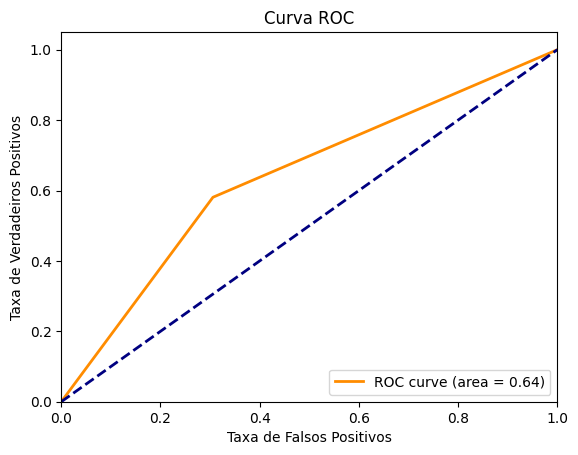

In [ ]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

O modelo tem uma chance de 64% de classificar corretamente um caso positivo aleatório como sendo mais provável de ser positivo do que um caso negativo aleatório.
A performance do modelo é melhor do que um chute aleatório, mas ainda comete erros significativos na classificação.

# 7) Alguma considerações:

A) O que é regressão logistica.

B) Por que a regressão logistica é um modelo de classificação.

C) Quais pontos em comum a regressão logistica tem da regressão linear.



a) Regressão logística é um modelo de aprendizagem supervisionada classificatório. Este modelo faz uma combinação linear das features e retorna em probabilidade entre 0 e 1. Em outras palavras, ele utiliza as varíaveis disponíveis e para responder se pertence a classe 0 ou 1.

b) É um modelo de classificação pois seu retorno não é uma predição contínua, mas um valor entre 0 ou 1. Ele diz se pertence ou não a classe. Neste caso, se a pessoa tem doença cardíaca ou não.

c)Regressão linear é um modelo de predição contínuo, ou seja, apresenta valores contínuos esperados dados os valores fornecidos. A regressão logistíca é um modelo de classficação binário, vai utilizar os dados para falar se aquela pessoa pertence ou não a uma classe. Elas tem em comum que ambas modelam a relação entre varíaveis dependentes e indepentes; utilizam função matemática para fazer a predição; utilizam metodos semelhantes para estimar os parâmetros e são usados para análise preditiva.